1.Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris

In [3]:
iris = load_iris() #Iris flower datase

#Create DataFrame
data = pd.DataFrame(iris.data, columns=iris.feature_names)#Features

#Add target column
data["Species"]=iris.target
print(data.head() )

   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  


2.Data Collection And EDA

In [4]:
data.shape #(rows,columns)

(150, 5)

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   sepal length (cm)  150 non-null    float64
 1   sepal width (cm)   150 non-null    float64
 2   petal length (cm)  150 non-null    float64
 3   petal width (cm)   150 non-null    float64
 4   Species            150 non-null    int64  
dtypes: float64(4), int64(1)
memory usage: 6.0 KB


In [6]:
#Target class distribution
data['Species'].value_counts()

,count
Species,
0,50
1,50
2,50


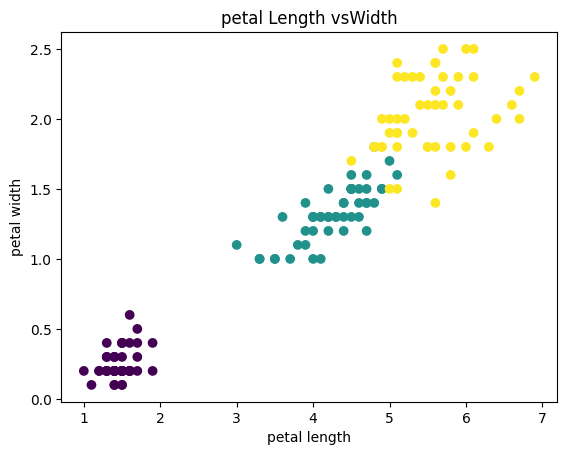

In [8]:
#scatter Plot
plt.scatter(data['petal length (cm)'], data['petal width (cm)'],c=data['Species'])
plt.xlabel('petal length')
plt.ylabel('petal width')
plt.title('petal Length vsWidth')
plt.show()

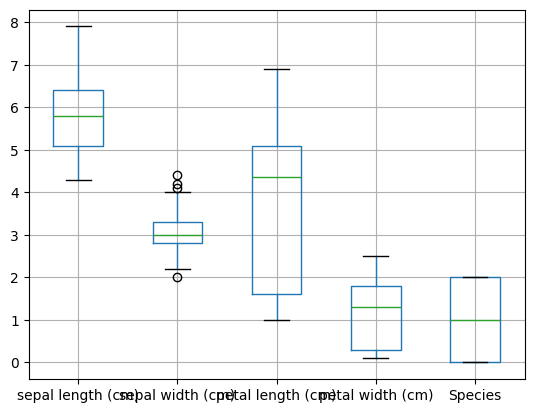

In [9]:
data.boxplot()
plt.show()

In [10]:
#Data splitting
x=data.iloc[:, :4] #Independant variable
y=data.iloc[:, -1]#Dependent variable

In [11]:
y.head()

,Species
0,0
1,0
2,0
3,0
4,0


In [12]:
#Data splitting
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)
x_train.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2


3.Model Building

In [21]:
#Create Desicion Tree model
from sklearn.tree import DecisionTreeClassifier
model = DecisionTreeClassifier(max_depth=3,random_state=42)
model.fit(x_train,y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [22]:
#Predict test data
y_pred = model.predict(x_test)
y_pred[:10]

array([1, 0, 2, 1, 1, 0, 1, 2, 1, 1])

In [23]:
#Classification Metrics
from sklearn.metrics import accuracy_score, precision_score,recall_score,f1_score
print("Train-Test Split Results")
print("Accuracy :", accuracy_score(y_test,y_pred))
print("Precision :",precision_score(y_test,y_pred,average="weighted"))
print("Recall :", recall_score(y_test,y_pred,average="weighted"))
print("F1 Score :", f1_score(y_test, y_pred, average="weighted"))


Train-Test Split Results
Accuracy : 1.0
Precision : 1.0
Recall : 1.0
F1 Score : 1.0


K-FOLD Cross Validation
*   Create K Fold
*   k-1 for Training and remaining fold for testing

In [26]:
#6. 5-Fold Cross Validation
from sklearn.model_selection import cross_validate,KFold
kf = KFold( n_splits=5, shuffle=True, random_state=42)
results = cross_validate(model,x,y,cv=kf, scoring=["accuracy","precision_weighted","recall_weighted","f1_weighted"])

In [28]:
#Average K-Fold Results
print("\n5-Fold Cross Validation Results:")
print("Acurracy :", np.mean(results["test_accuracy"]))
print("Precision:", np.mean(results["test_precision_weighted"]))
print("Recall :",np.mean(results["test_recall_weighted"]))
print("F1 Score :",np.mean(results["test_f1_weighted"]))


5-Fold Cross Validation Results:
Acurracy : 0.9533333333333334
Precision: 0.9577676767676767
Recall : 0.9533333333333334
F1 Score : 0.953277061103148
